In [3]:
import sys
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from accelerate import Accelerator

# Add src/ directory to Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src")))

In [2]:
from qwen import load_qwen
from lora import LoRALinear
from processor import load_and_preprocess
from data import process_sequences

/Users/saamnazem/M2_stuff/M2_venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/saamnazem/M2_stuff/M2_venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ✅ Force everything to CPU
device = torch.device("cpu")

# ✅ Context Lengths to Test
context_lengths = [128, 512, 768]

# ✅ Iterate Over Context Lengths
for max_ctx_length in context_lengths:
    print(f"\n🔹 Running Experiment with Context Length: {max_ctx_length}")

    # ✅ Load model and move to CPU
    model, tokenizer = load_qwen()
    model.to(device)

    # ✅ Apply LoRA to Query & Value Projection Layers
    lora_rank = 8
    for layer in model.model.layers:
        layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)
        layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

    # ✅ Load dataset
    train_texts, val_texts = load_and_preprocess("coursework/lotka_volterra_data.h5", num_systems=100, time_steps=10, fraction=0.8)

    # ✅ Tokenize dataset with sliding windows
    def process_sequences(texts, tokenizer, max_length=512, stride=256):
        all_input_ids = []
        for text in texts:
            encoding = tokenizer(text, return_tensors="pt", add_special_tokens=False)
            seq_ids = encoding.input_ids[0]

            for i in range(0, len(seq_ids), stride):
                chunk = seq_ids[i : i + max_length]
                if len(chunk) < max_length:
                    chunk = torch.cat([chunk, torch.full((max_length - len(chunk),), tokenizer.pad_token_id)])
                all_input_ids.append(chunk)
        return torch.stack(all_input_ids)

    # ✅ Convert tokenized text into tensors
    train_input_ids = process_sequences(train_texts, tokenizer, max_ctx_length)
    val_input_ids = process_sequences(val_texts, tokenizer, max_ctx_length)

    # ✅ Prepare DataLoaders
    batch_size = 2
    train_dataset = TensorDataset(train_input_ids)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_dataset = TensorDataset(val_input_ids)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

    # ✅ Optimizer & Scheduler
    learning_rate = 0.0001
    optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=learning_rate, weight_decay=0.02)

    # ✅ Use Accelerator for efficient training
    accelerator = Accelerator()
    model, optimizer, train_loader = accelerator.prepare(model, optimizer, train_loader)

    train_losses = []
    val_losses = []
    eval_interval = 100  # Evaluate every 1000 steps

    for param in model.parameters():
        param.data = param.data.to("cpu")
        if param.grad is not None:
            param.grad.data = param.grad.data.to("cpu")

    for buffer in model.buffers():
        buffer.data = buffer.data.to("cpu")

    # ✅ Train LoRA Model
    model.train()
    steps = 0
    while steps < 400:
        progress_bar = tqdm(train_loader, desc=f"Context {max_ctx_length} | Steps {steps}")
        for (batch,) in progress_bar:
            optimizer.zero_grad()
            batch = batch.to(device, dtype=torch.long)

            outputs = model(batch, labels=batch)
            loss = outputs.loss
            accelerator.backward(loss)
            optimizer.step()
            steps += 1

            train_losses.append(loss.item())
            progress_bar.set_postfix(loss=loss.item())

            # ✅ Evaluate validation loss
            if steps % eval_interval == 0:
                model.eval()
                val_loss_total = 0
                with torch.no_grad():
                    for (val_batch,) in val_loader:
                        val_batch = val_batch.to(device, dtype=torch.long)
                        val_outputs = model(val_batch, labels=val_batch)
                        val_loss_total += val_outputs.loss.item()
                avg_val_loss = val_loss_total / len(val_loader)
                val_losses.append(avg_val_loss)
                print(f"Step {steps}: Validation Loss = {avg_val_loss}")
                model.train()

            if steps >= 400:
                break

    # ✅ Save Model Checkpoint
    torch.save(model.state_dict(), f"models/lora_qwen2.5_ctx{max_ctx_length}_testing.pth")

    # ✅ Save Train & Validation Losses to CSV
    pd.DataFrame({"train_loss": train_losses}).to_csv(f"csv/train_loss_ctx{max_ctx_length}.csv", index=False)
    pd.DataFrame({"val_loss": val_losses}).to_csv(f"csv/val_loss_ctx{max_ctx_length}.csv", index=False)

    print(f"\n✅ Finished Experiment with Context Length {max_ctx_length}\n")


### Final Validation Loss 

In [8]:
# ✅ Load validation data once
_, val_texts = load_and_preprocess("../coursework/lotka_volterra_data.h5", num_systems=100, time_steps=10, fraction=0.8)

device = torch.device("cpu")
# ✅ Loop over context lengths
context_lengths = [128, 512, 768]
results = []

for ctx in context_lengths:
    print(f"\n🔍 Evaluating Model with Context Length: {ctx}")
    
    # Load model & tokenizer
    model, tokenizer = load_qwen()
    model.to(device)

    # Apply LoRA
    lora_rank = 8
    for layer in model.model.layers:
        layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=lora_rank)
        layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=lora_rank)

    # Load LoRA weights
    model_path = f"../models/lora_qwen2.5_ctx{ctx}_testing.pth"
    model.load_state_dict(torch.load(model_path, map_location=device))

    # Prepare val_loader for this context
    val_input_ids = process_sequences(val_texts, tokenizer, max_length=ctx)
    val_dataset = TensorDataset(val_input_ids)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

    # Compute validation loss
    model.eval()
    val_loss_total = 0
    with torch.no_grad():
        for (val_batch,) in val_loader:
            val_batch = val_batch.to(device, dtype=torch.long)
            val_outputs = model(val_batch, labels=val_batch)
            val_loss_total += val_outputs.loss.item()
    avg_val_loss = val_loss_total / len(val_loader)
    
    results.append((ctx, avg_val_loss))
    print(f"✅ Context Length {ctx}: Final Validation Loss = {avg_val_loss:.4f}")

# ✅ Optional: Print summary
print("\n📊 Final Validation Losses:")
for ctx, loss in results:
    print(f"Context Length {ctx}: {loss:.4f}")


🔍 Evaluating Model with Context Length: 128
✅ Context Length 128: Final Validation Loss = 0.2063

🔍 Evaluating Model with Context Length: 512
✅ Context Length 512: Final Validation Loss = 0.1503

🔍 Evaluating Model with Context Length: 768
✅ Context Length 768: Final Validation Loss = 0.1083

📊 Final Validation Losses:
Context Length 128: 0.2063
Context Length 512: 0.1503
Context Length 768: 0.1083


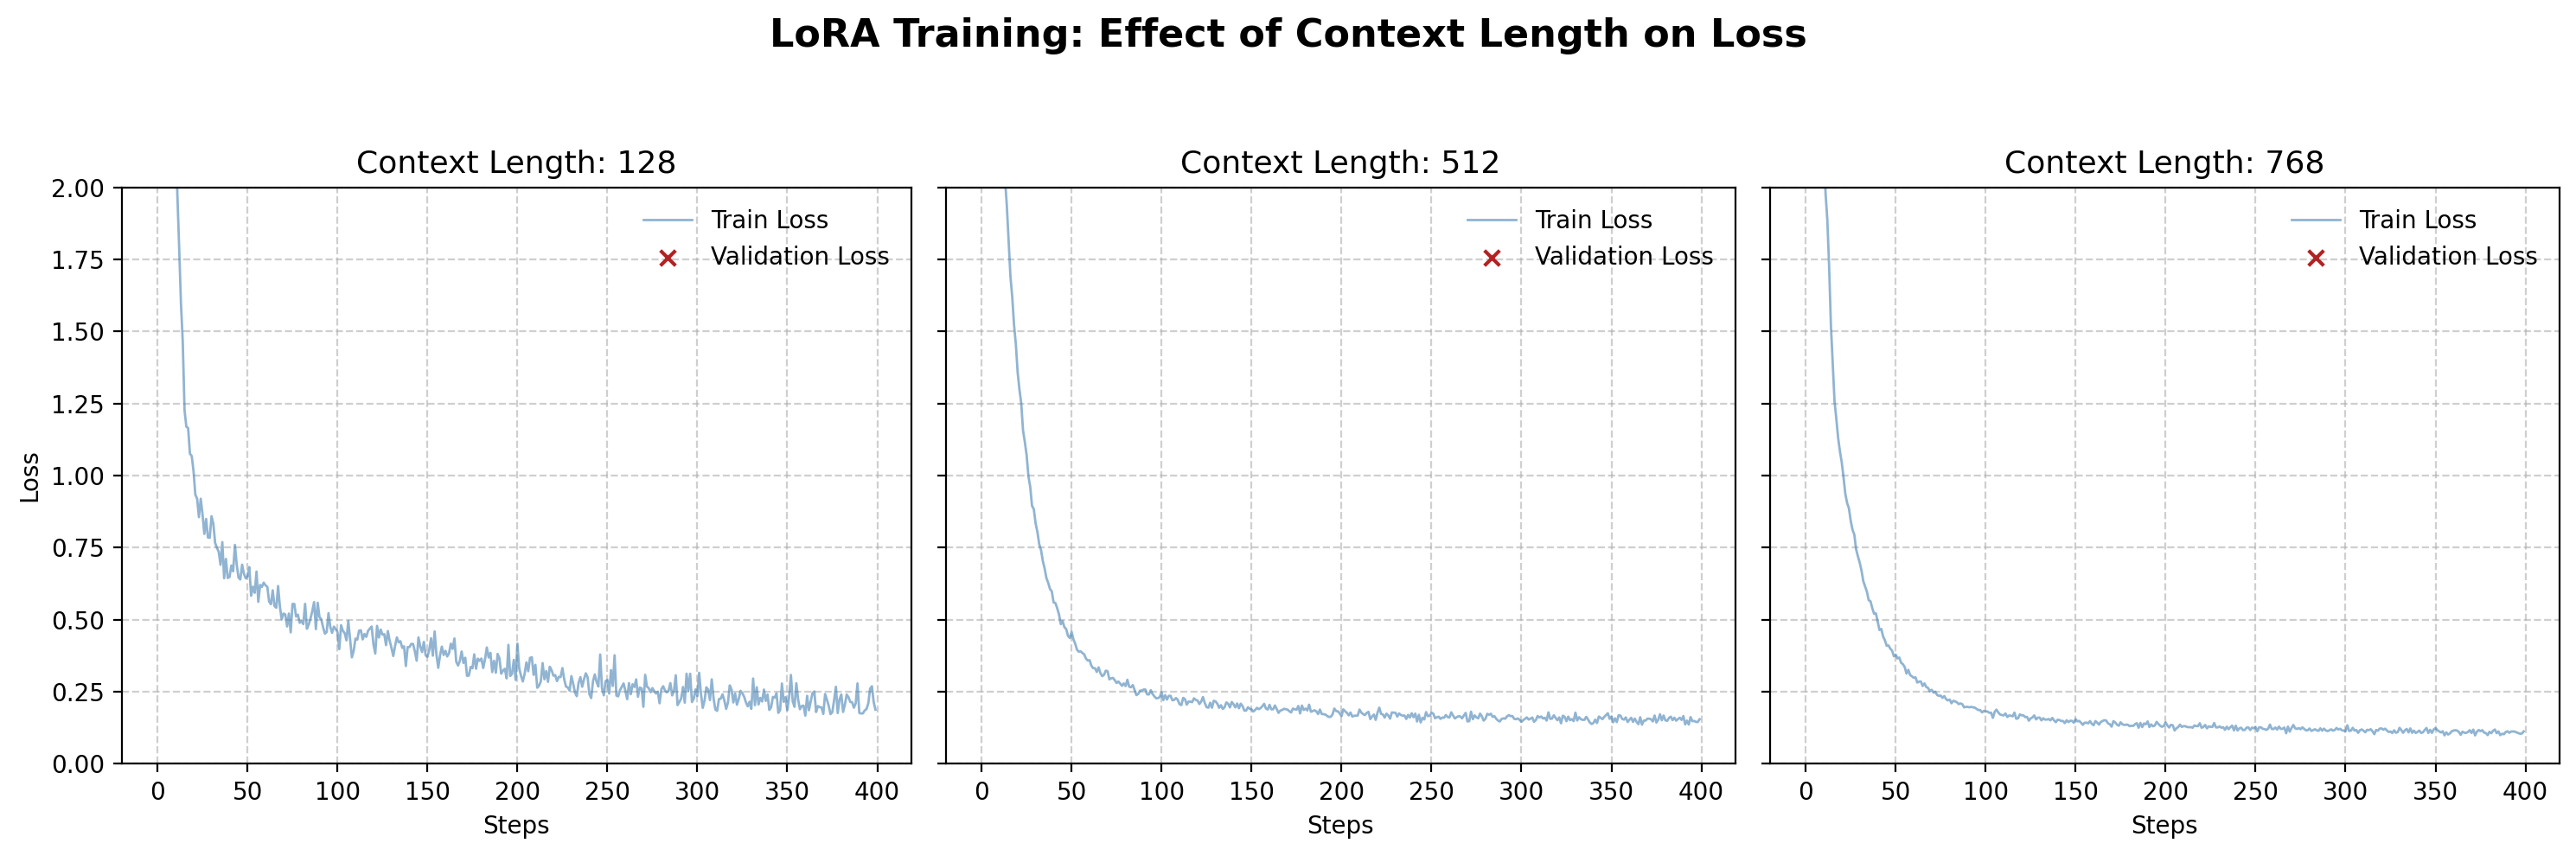

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ✅ Define Context Lengths
context_lengths = [128, 512, 768]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=200, sharey=True)
fig.suptitle("LoRA Training: Effect of Context Length on Loss", fontsize=16, fontweight='bold')

for i, ctx in enumerate(context_lengths):
    # Load losses
    train_losses = pd.read_csv(f"../csv/train_loss_ctx{ctx}.csv")["train_loss"].values
    val_losses = pd.read_csv(f"../csv/val_loss_ctx{ctx}.csv")["val_loss"].values
    val_steps = np.linspace(0, len(train_losses), len(val_losses))

    # Plot train loss
    axes[i].plot(train_losses, label="Train Loss", color="steelblue", linewidth=1, alpha=0.6)

    # Plot validation loss
    axes[i].scatter(val_steps, val_losses, label="Validation Loss", color="firebrick", marker="x", s=40)

    # Formatting
    axes[i].set_title(f"Context Length: {ctx}", fontsize=13)
    axes[i].set_xlabel("Steps")
    axes[i].set_ylim(0, 2)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend(frameon=False)

    if i == 0:
        axes[i].set_ylabel("Loss")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

